# 🏦 Credit Risk Assessment & Loan Default Prediction

**Objective:** Build and evaluate a supervised learning model to predict the likelihood of a borrower defaulting on a loan based on their financial profile.

### Step 1: Dataset Generation & Splitting
To ensure reproducibility, we will generate a realistic financial portfolio containing:
* `Credit_Score` (Range: 300 - 850)
* `Annual_Income` (In USD)
* `Debt_to_Income_Ratio` (Percentage of income going to debt)
* `Defaulted` (Target variable: 1 = Yes, 0 = No)

We will then split the data into an 80% training set and a 20% validation testing set.

### Step 2: Training a Decision Tree Classifier
We will deploy a **Decision Tree Classifier**. Decision trees are highly interpretable algorithms that split data based on feature thresholds (e.g., if a credit score is below a certain value, move to the next branch), making them highly effective for financial scoring models.

### Step 3: Performance Analysis
We will analyze the model's predictive power using:
1. **Confusion Matrix:** To track True Negatives (correctly identifying safe borrowers) and False Negatives (missing a risky borrower).
2. **ROC Curve & AUC:** To evaluate how well the model separates the two classes across different probability thresholds.

Model Accuracy Score: 90.42%

Detailed Performance Matrix:

                precision    recall  f1-score   support

 Approved/Safe       0.91      0.99      0.95       216
Defaulted/Risk       0.60      0.12      0.21        24

      accuracy                           0.90       240
     macro avg       0.76      0.56      0.58       240
  weighted avg       0.88      0.90      0.87       240



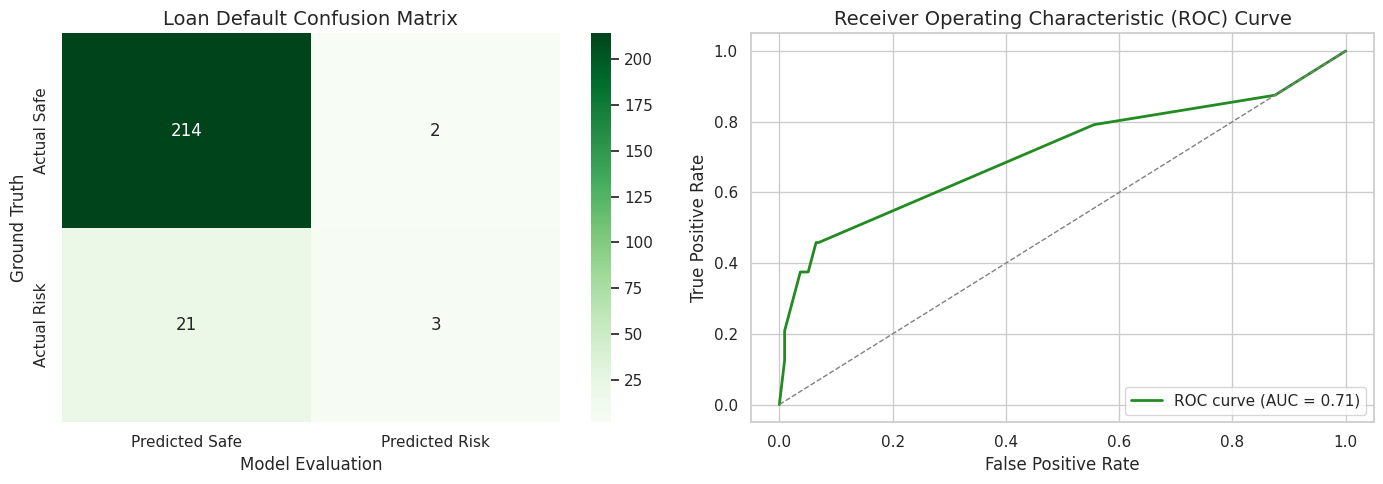

In [1]:
# 1. IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Set visual theme
sns.set_theme(style="whitegrid")

# 2. GENERATE REALISTIC LOAN DATASET
np.random.seed(42)
n_samples = 1200

# Generating realistic distributions
credit_score = np.random.normal(660, 85, n_samples).clip(300, 850)
income = np.random.normal(60000, 25000, n_samples).clip(15000, 160000)
debt_to_income = np.random.beta(2, 5, n_samples) * 100

# Base risk on combinations of features + random variance
log_odds = (-0.012 * credit_score) + (0.06 * debt_to_income) - (0.000015 * income) + 3.5
prob_default = 1 / (1 + np.exp(-log_odds))
defaulted = np.random.binomial(1, prob_default)

# Create DataFrame
df = pd.DataFrame({
    'Credit_Score': credit_score,
    'Annual_Income': income,
    'Debt_to_Income_Ratio': debt_to_income,
    'Defaulted': defaulted
})

# 3. PREPROCESS AND SPLIT DATA
X = df.drop(columns=['Defaulted'])
y = df['Defaulted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for uniformity
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. TRAIN THE MODEL
# Initializing a Decision Tree with controlled depth to avoid overfitting
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict outcomes and probabilities
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 5. PRINT METRICS REPORT
print(f"Model Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Performance Matrix:\n")
print(classification_report(y_test, y_pred, target_names=['Approved/Safe', 'Defaulted/Risk']))

# 6. PERFORMANCE VISUALIZATION
plt.figure(figsize=(14, 5))

# Plot 1: Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Safe', 'Predicted Risk'],
            yticklabels=['Actual Safe', 'Actual Risk'])
plt.title('Loan Default Confusion Matrix', fontsize=14)
plt.ylabel('Ground Truth')
plt.xlabel('Model Evaluation')

# Plot 2: ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='forestgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()